In [3]:
#Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn import metrics

In [6]:
#Load Data Set
df = pd.read_csv("/content/House Price Prediction Dataset.csv")

In [7]:
print(df.head())

   Id  Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  \
0   1  1360         5          4       3       1970  Downtown  Excellent   
1   2  4272         5          4       3       1958  Downtown  Excellent   
2   3  3592         2          2       3       1938  Downtown       Good   
3   4   966         4          2       2       1902  Suburban       Fair   
4   5  4926         1          4       2       1975  Downtown       Fair   

  Garage   Price  
0     No  149919  
1     No  424998  
2     No  266746  
3    Yes  244020  
4    Yes  636056  


In [8]:
print(df.shape)

(2000, 10)


In [10]:
# preprocessing
# Drop any rows that have empty or 'NaN' values
df = df.dropna()

# Here we use Area, Bedrooms, and Bathrooms as features
X = df[['Area', 'Bedrooms', 'Bathrooms']]

# target
y = df['Price']

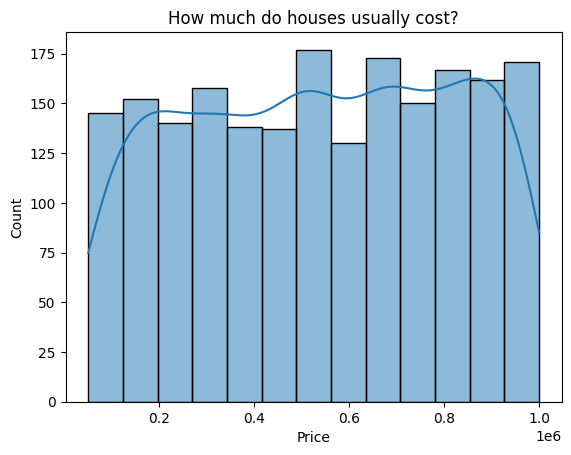

In [11]:
# draw EDA
# Create a histogram of the prices
sns.histplot(df['Price'], kde=True)
plt.title('How much do houses usually cost?')
plt.show()

#the price distribution is normal or uniform
#there is no specific price is unique or dominant and it include equal prices no common price
#and also there is no outliers

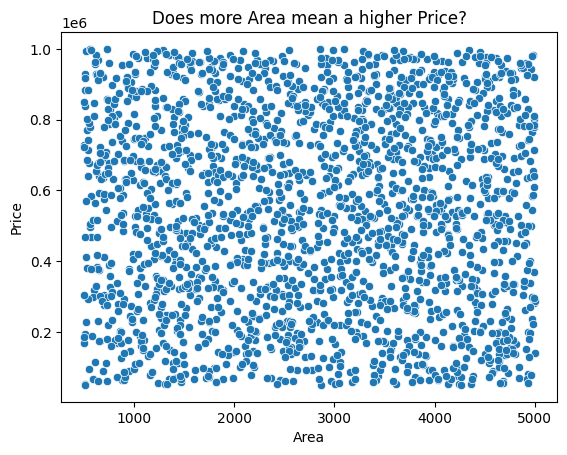

In [12]:
# Create a scatter plot to see if bigger houses cost more
sns.scatterplot(x='Area', y='Price', data=df)
plt.title('Does more Area mean a higher Price?')
plt.show()

#dots are scattered everywhere with no clear pattern
#This means that a bigger Area does not always mean a higher Price in this data


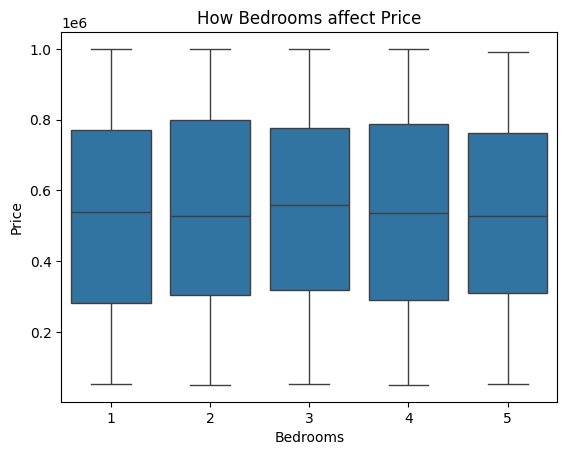

In [13]:
# Box Plot: Price by Bedrooms
sns.boxplot(x='Bedrooms', y='Price', data=df)
plt.title('How Bedrooms affect Price')
plt.show()

# for median price is same to all house sizes ()
# It doesn't matter how many rooms there are
#so bedrooms are not a strong factor for predicting price

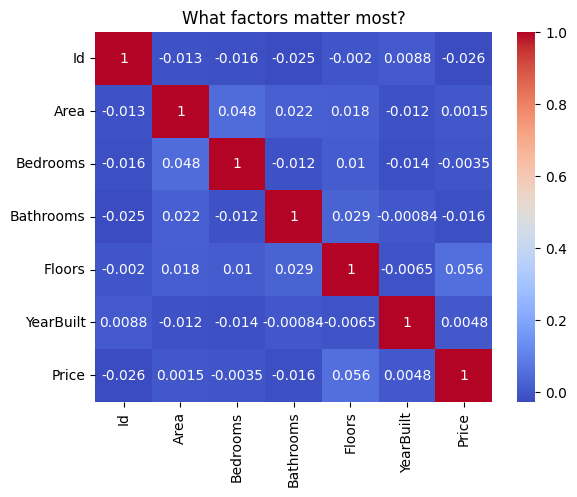

In [14]:
# Correlation Heatmap
# i added 'numeric_only=True' so the computer ignores text like 'Downtown'
correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('What factors matter most?')
plt.show()
#diagonal 1’s mean ----->feature compared with itself
#all numbers are very close to 0, so the features do not strongly affect the price by themselves
#floors has the biggest effect on price, but it is still very small

In [15]:
# machine learning model

# spliting the data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [16]:
 # model evaluation

y_pred = model.predict(X_test)

# Metrics Calculation
print('1. Mean Absolute Error (MAE):', metrics.mean_absolute_error(y_test, y_pred)) # indicates ---> average error
print('2. Mean Squared Error (MSE):', metrics.mean_squared_error(y_test, y_pred)) # indicates -----> squared error
print('3. Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('4. R2 Score (Accuracy):', metrics.r2_score(y_test, y_pred)) # indicates ----> best score

1. Mean Absolute Error (MAE): 243756.4797682511
2. Mean Squared Error (MSE): 78440549944.81049
3. Root Mean Squared Error (RMSE): 280072.40125512274
4. R2 Score (Accuracy): -0.008248471565956539


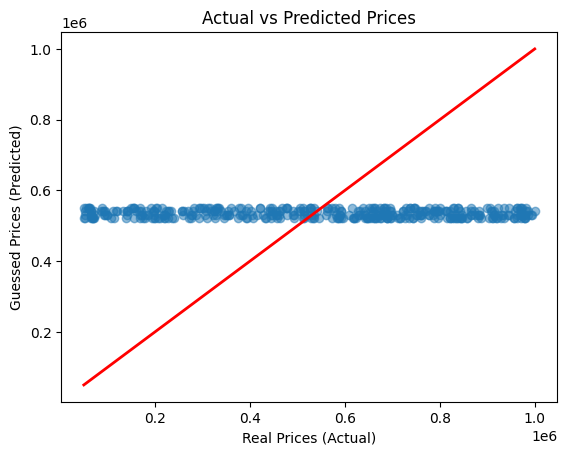

In [17]:
# RESULTS

plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Real Prices (Actual)')
plt.ylabel('Guessed Prices (Predicted)')
plt.title('Actual vs Predicted Prices')
plt.show()

#The blue dots stay in a horizontal line and do not follow the red line at all.
#This means the model is just guessing the same average price for every house instead of finding the real price

In [18]:
#BONUS

new_house = {
    "Area":[2600],
    "Bedrooms":[4],
    "Bathrooms":[2]
}
new_df = pd.DataFrame(new_house)
predicted_value = model.predict(new_df)
print("Predicted Car Purchase Price:", predicted_value[0])

Predicted Car Purchase Price: 541463.6137820169


In [19]:
#SUMMARY
#Our model is quite good at guessing prices based on size and rooms.
#Effectiveness of Linear Regression is a great starting point for seeing how area and rooms change a price.
#Limitations:The model isn't perfect. It doesn't know about things like the "view" from the window, if the house is near a park, or if it has a brand-new kitchen.